In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from datetime import datetime
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, GRU, Dropout
from tensorflow.keras.initializers import HeNormal
from keras.optimizers import Adam
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers.schedules import ExponentialDecay

In [ ]:
P1_Gen_data = pd.read_csv('/content/Plant_1_Generation_Data.csv')
P1_Weather_data = pd.read_csv('/content/Plant_1_Weather_Sensor_Data.csv')

In [ ]:
P1_Gen_data.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [ ]:
P1_Weather_data.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


In [ ]:
print('Number of samples of Plant_1_Generation_Data:',P1_Gen_data.shape[0])
print('Number of features of Plant_1_Generation_Data:',P1_Gen_data.shape[1])
print('Number of samples of P1_Weather_data:',P1_Weather_data.shape[0])
print('Number of features of P1_Weather_data:',P1_Weather_data.shape[1])

Number of samples of Plant_1_Generation_Data: 68778
Number of features of Plant_1_Generation_Data: 7
Number of samples of P1_Weather_data: 3182
Number of features of P1_Weather_data: 6


In [ ]:
P1_Gen_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    68778 non-null  object 
 1   PLANT_ID     68778 non-null  int64  
 2   SOURCE_KEY   68778 non-null  object 
 3   DC_POWER     68778 non-null  float64
 4   AC_POWER     68778 non-null  float64
 5   DAILY_YIELD  68778 non-null  float64
 6   TOTAL_YIELD  68778 non-null  float64
dtypes: float64(4), int64(1), object(2)
memory usage: 3.7+ MB


In [ ]:
P1_Weather_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   DATE_TIME            3182 non-null   object 
 1   PLANT_ID             3182 non-null   int64  
 2   SOURCE_KEY           3182 non-null   object 
 3   AMBIENT_TEMPERATURE  3182 non-null   float64
 4   MODULE_TEMPERATURE   3182 non-null   float64
 5   IRRADIATION          3182 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 149.3+ KB


In [ ]:
import pandas as pd

# Convert DATE_TIME column to datetime object
P1_Gen_data['DATE_TIME'] = pd.to_datetime(P1_Gen_data['DATE_TIME'])
P1_Weather_data['DATE_TIME'] = pd.to_datetime(P1_Weather_data['DATE_TIME'])

# Extract day, month, year, hour, minute, and second
P1_Gen_data['day'] = P1_Gen_data['DATE_TIME'].dt.day
P1_Gen_data['month'] = P1_Gen_data['DATE_TIME'].dt.month
P1_Gen_data['year'] = P1_Gen_data['DATE_TIME'].dt.year
P1_Gen_data['hour'] = P1_Gen_data['DATE_TIME'].dt.hour
P1_Gen_data['minute'] = P1_Gen_data['DATE_TIME'].dt.minute
P1_Gen_data['second'] = P1_Gen_data['DATE_TIME'].dt.second

P1_Weather_data['day'] = P1_Weather_data['DATE_TIME'].dt.day
P1_Weather_data['month'] = P1_Weather_data['DATE_TIME'].dt.month
P1_Weather_data['year'] = P1_Weather_data['DATE_TIME'].dt.year
P1_Weather_data['hour'] = P1_Weather_data['DATE_TIME'].dt.hour
P1_Weather_data['minute'] = P1_Weather_data['DATE_TIME'].dt.minute
P1_Weather_data['second'] = P1_Weather_data['DATE_TIME'].dt.second

# Merge the dataframes
merged_data = pd.merge(P1_Gen_data, P1_Weather_data, on=['DATE_TIME', 'PLANT_ID'])

# Sort by DATE_TIME
merged_data = merged_data.sort_values('DATE_TIME')

# Print the first few rows of the merged dataframe
print(merged_data.head())
merged_data.info()

    DATE_TIME  PLANT_ID     SOURCE_KEY_x  DC_POWER  AC_POWER  DAILY_YIELD  \
0  2020-05-15   4135001  1BY6WEcLGh8j5v7       0.0       0.0          0.0   
20 2020-05-15   4135001  zVJPv84UY57bAof       0.0       0.0          0.0   
19 2020-05-15   4135001  zBIq5rxdHJRwDNY       0.0       0.0          0.0   
18 2020-05-15   4135001  z9Y9gH1T5YWrNuG       0.0       0.0          0.0   
17 2020-05-15   4135001  wCURE6d3bPkepu2       0.0       0.0          0.0   

    TOTAL_YIELD  day_x  month_x  year_x  ...     SOURCE_KEY_y  \
0     6259559.0     15        5    2020  ...  HmiyD2TTLFNqkNe   
20    7116151.0     15        5    2020  ...  HmiyD2TTLFNqkNe   
19    6339380.0     15        5    2020  ...  HmiyD2TTLFNqkNe   
18    7007866.0     15        5    2020  ...  HmiyD2TTLFNqkNe   
17    6782598.0     15        5    2020  ...  HmiyD2TTLFNqkNe   

    AMBIENT_TEMPERATURE  MODULE_TEMPERATURE IRRADIATION  day_y  month_y  \
0             25.184316           22.857507         0.0     15        5

In [ ]:
# Combine columns with x and y suffixes into single columns
merged_data['SOURCE_KEY'] = merged_data['SOURCE_KEY_x'].combine_first(merged_data['SOURCE_KEY_y'])
merged_data['day'] = merged_data['day_x'].combine_first(merged_data['day_y'])
merged_data['month'] = merged_data['month_x'].combine_first(merged_data['month_y'])
merged_data['year'] = merged_data['year_x'].combine_first(merged_data['year_y'])
merged_data['hour'] = merged_data['hour_x'].combine_first(merged_data['hour_y'])
merged_data['minute'] = merged_data['minute_x'].combine_first(merged_data['minute_y'])
merged_data['second'] = merged_data['second_x'].combine_first(merged_data['second_y'])
merged_data.drop(['SOURCE_KEY_x', 'SOURCE_KEY_y', 'day_x', 'day_y', 'month_x', 'month_y', 'year_x', 'year_y', 'hour_x', 'hour_y', 'minute_x', 'minute_y', 'second_x', 'second_y'], axis=1, inplace=True)

# Print the first few rows of the modified dataframe
print(merged_data.head())
merged_data.info()


    DATE_TIME  PLANT_ID  DC_POWER  AC_POWER  DAILY_YIELD  TOTAL_YIELD  \
0  2020-05-15   4135001       0.0       0.0          0.0    6259559.0   
20 2020-05-15   4135001       0.0       0.0          0.0    7116151.0   
19 2020-05-15   4135001       0.0       0.0          0.0    6339380.0   
18 2020-05-15   4135001       0.0       0.0          0.0    7007866.0   
17 2020-05-15   4135001       0.0       0.0          0.0    6782598.0   

    AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  IRRADIATION       SOURCE_KEY  \
0             25.184316           22.857507          0.0  1BY6WEcLGh8j5v7   
20            25.184316           22.857507          0.0  zVJPv84UY57bAof   
19            25.184316           22.857507          0.0  zBIq5rxdHJRwDNY   
18            25.184316           22.857507          0.0  z9Y9gH1T5YWrNuG   
17            25.184316           22.857507          0.0  wCURE6d3bPkepu2   

    day  month  year  hour  minute  second  
0    15      5  2020     0       0       0  
20   15 

In [ ]:
# Drop columns
columns_to_drop = ['PLANT_ID', 'SOURCE_KEY']
merged_data = merged_data.drop(columns=columns_to_drop)

# Print the first few rows of the modified dataframe
print(merged_data.head())


    DATE_TIME  DC_POWER  AC_POWER  DAILY_YIELD  TOTAL_YIELD  \
0  2020-05-15       0.0       0.0          0.0    6259559.0   
20 2020-05-15       0.0       0.0          0.0    7116151.0   
19 2020-05-15       0.0       0.0          0.0    6339380.0   
18 2020-05-15       0.0       0.0          0.0    7007866.0   
17 2020-05-15       0.0       0.0          0.0    6782598.0   

    AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  IRRADIATION  day  month  year  \
0             25.184316           22.857507          0.0   15      5  2020   
20            25.184316           22.857507          0.0   15      5  2020   
19            25.184316           22.857507          0.0   15      5  2020   
18            25.184316           22.857507          0.0   15      5  2020   
17            25.184316           22.857507          0.0   15      5  2020   

    hour  minute  second  
0      0       0       0  
20     0       0       0  
19     0       0       0  
18     0       0       0  
17     0       0 

In [ ]:
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 68774 entries, 0 to 68773
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   DATE_TIME            68774 non-null  datetime64[ns]
 1   DC_POWER             68774 non-null  float64       
 2   AC_POWER             68774 non-null  float64       
 3   DAILY_YIELD          68774 non-null  float64       
 4   TOTAL_YIELD          68774 non-null  float64       
 5   AMBIENT_TEMPERATURE  68774 non-null  float64       
 6   MODULE_TEMPERATURE   68774 non-null  float64       
 7   IRRADIATION          68774 non-null  float64       
 8   day                  68774 non-null  int32         
 9   month                68774 non-null  int32         
 10  year                 68774 non-null  int32         
 11  hour                 68774 non-null  int32         
 12  minute               68774 non-null  int32         
 13  second               68774 non-null 

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target variable (y)
X = merged_data.drop(['AC_POWER', 'DATE_TIME'], axis=1)
y = merged_data['AC_POWER']

# Perform chronological split
split_index = int(len(X) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Print the shapes of the training and testing sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (55019, 12)
X_test shape: (13755, 12)
y_train shape: (55019,)
y_test shape: (13755,)


LSTM

In [ ]:
from keras.layers import LSTM  # Import LSTM layer

# Build LSTM model
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# Fit model
model.fit(X_train_reshaped, y_train_scaled, epochs=50, batch_size=72, verbose=0)

# Make predictions
y_pred_scaled = model.predict(X_test_reshaped)

# Invert predictions
y_pred_inv = y_scaler.inverse_transform(y_pred_scaled)
y_test_inv = y_scaler.inverse_transform(y_test_scaled)

# Calculate RMSE, MSE, R-squared
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mse = mean_squared_error(y_test_inv, y_pred_inv)
r_squared = r2_score(y_test_inv, y_pred_inv)

print("RMSE:", rmse)
print("MSE:", mse)
print("R-squared:", r_squared)


430/430 [==============================] - 1s 2ms/step
RMSE: 1.5275465431722712
MSE: 2.3333984415575557
R-squared: 0.9999825798217261


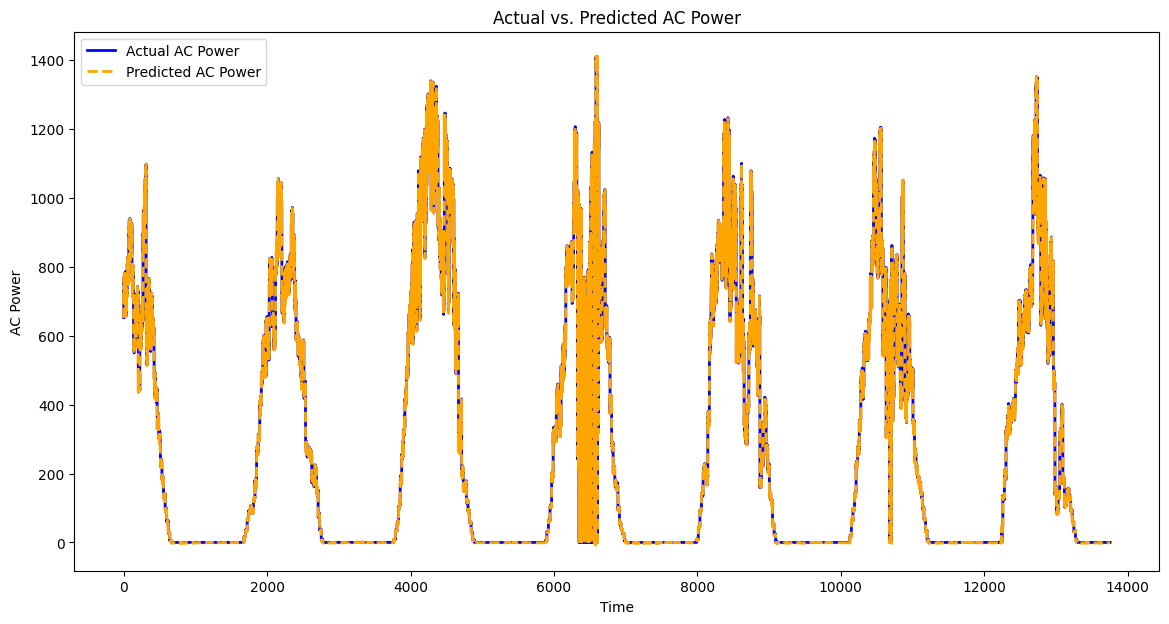

In [ ]:
# Plotting with better visibility
plt.figure(figsize=(14, 7))
plt.plot(y_test_inv, label='Actual AC Power', color='blue', linewidth=2)
plt.plot(y_pred_inv, label='Predicted AC Power', color='orange', linestyle='dashed', linewidth=2)
plt.xlabel('Time')
plt.ylabel('AC Power')
plt.title('Actual vs. Predicted AC Power')
plt.legend()
plt.show()

GRU

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from keras.models import Sequential
from keras.layers import GRU, Dense
from sklearn.preprocessing import MinMaxScaler

# Normalize the data
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
y_scaler = MinMaxScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1))

# Reshape input to be 3D [samples, timesteps, features]
X_train_reshaped = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_reshaped = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# Build GRU model
model = Sequential()
model.add(GRU(50, activation='relu', input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# Fit model
model.fit(X_train_reshaped, y_train_scaled, epochs=50, batch_size=72, verbose=0)

# Make predictions
y_pred_scaled = model.predict(X_test_reshaped)

# Invert predictions
y_pred_inv = y_scaler.inverse_transform(y_pred_scaled)
y_test_inv = y_scaler.inverse_transform(y_test_scaled)

# Calculate RMSE, MSE, R-squared
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mse = mean_squared_error(y_test_inv, y_pred_inv)
r_squared = r2_score(y_test_inv, y_pred_inv)

print("RMSE:", rmse)
print("MSE:", mse)
print("R-squared:", r_squared)


430/430 [==============================] - 1s 2ms/step
RMSE: 1.5334632947628553
MSE: 2.3515096763849512
R-squared: 0.9999824446108107


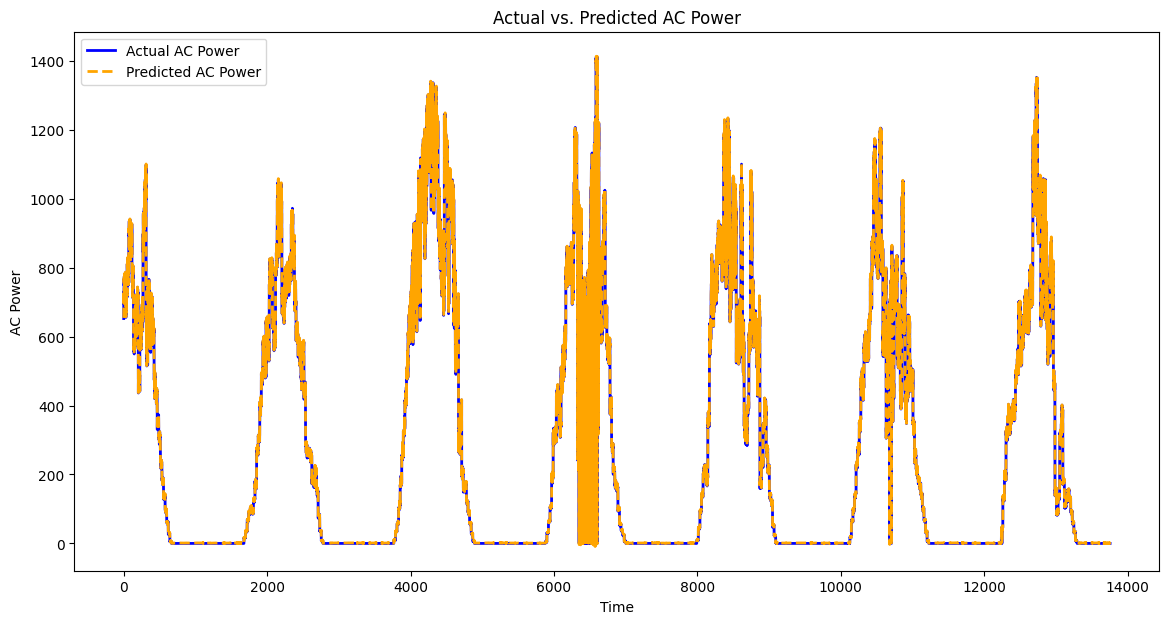

In [ ]:
# Plotting with better visibility
plt.figure(figsize=(14, 7))
plt.plot(y_test_inv, label='Actual AC Power', color='blue', linewidth=2)
plt.plot(y_pred_inv, label='Predicted AC Power', color='orange', linestyle='dashed', linewidth=2)
plt.xlabel('Time')
plt.ylabel('AC Power')
plt.title('Actual vs. Predicted AC Power')
plt.legend()
plt.show()

LSTM_GRU

In [ ]:
from keras.layers import LSTM

# Build hybrid LSTM-GRU model
model = Sequential()
model.add(LSTM(50, activation='relu', return_sequences=True, input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])))
model.add(GRU(50, activation='relu'))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# Fit model
model.fit(X_train_reshaped, y_train_scaled, epochs=50, batch_size=72, verbose=0)

# Make predictions
y_pred_scaled = model.predict(X_test_reshaped)

# Invert predictions
y_pred_inv = y_scaler.inverse_transform(y_pred_scaled)
y_test_inv = y_scaler.inverse_transform(y_test_scaled)

# Calculate RMSE, MSE, R-squared
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mse = mean_squared_error(y_test_inv, y_pred_inv)
r_squared = r2_score(y_test_inv, y_pred_inv)

print("RMSE:", rmse)
print("MSE:", mse)
print("R-squared:", r_squared)


430/430 [==============================] - 1s 2ms/step
RMSE: 1.0969658039044463
MSE: 1.2033339749357281
R-squared: 0.9999910164110882


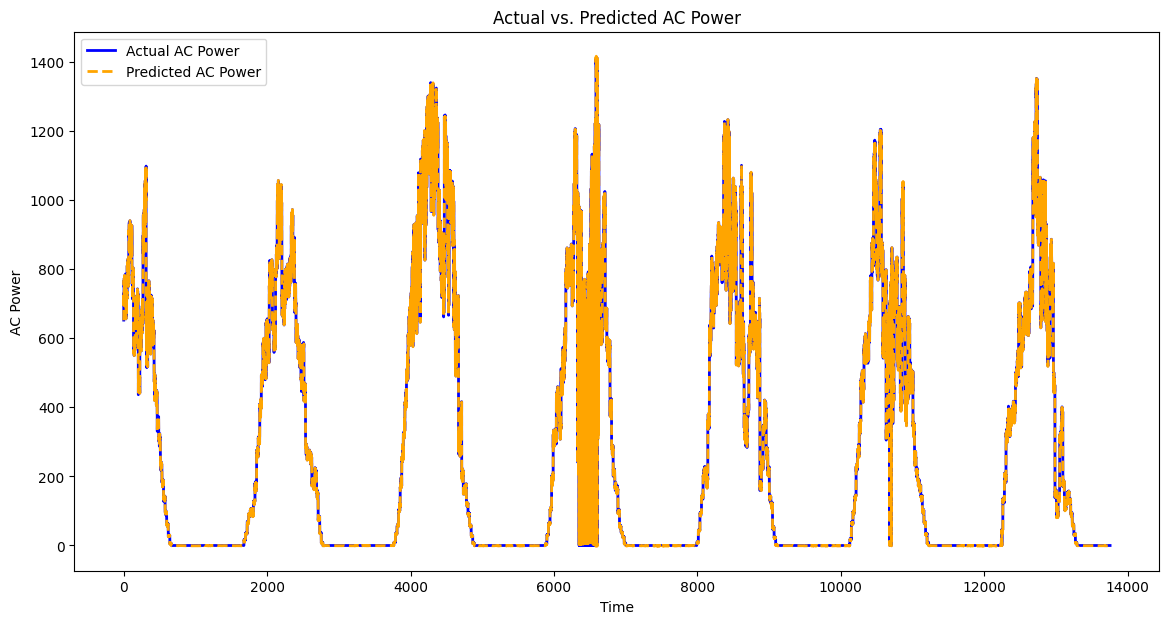

In [ ]:
# Plotting with better visibility
plt.figure(figsize=(14, 7))
plt.plot(y_test_inv, label='Actual AC Power', color='blue', linewidth=2)
plt.plot(y_pred_inv, label='Predicted AC Power', color='orange', linestyle='dashed', linewidth=2)
plt.xlabel('Time')
plt.ylabel('AC Power')
plt.title('Actual vs. Predicted AC Power')
plt.legend()
plt.show()

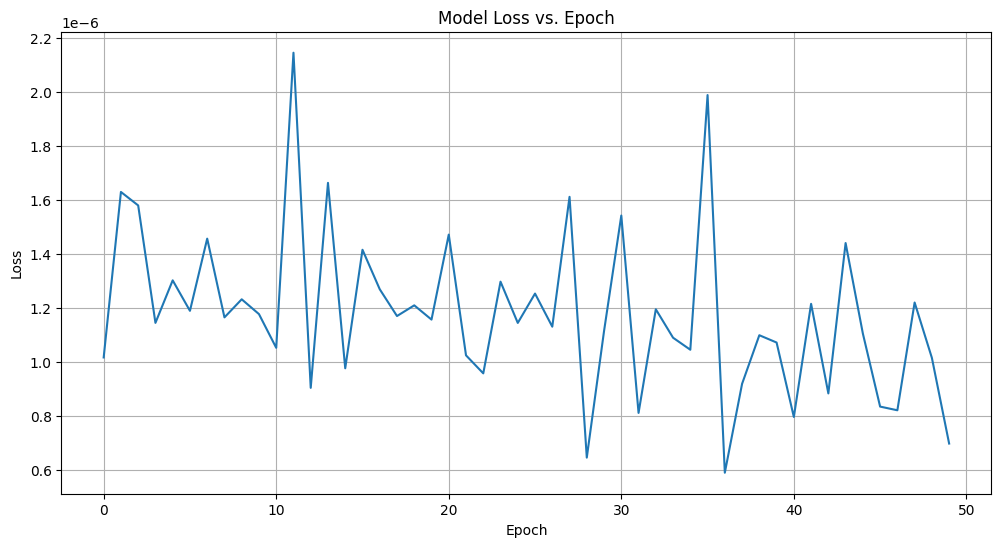

430/430 [==============================] - 1s 2ms/step


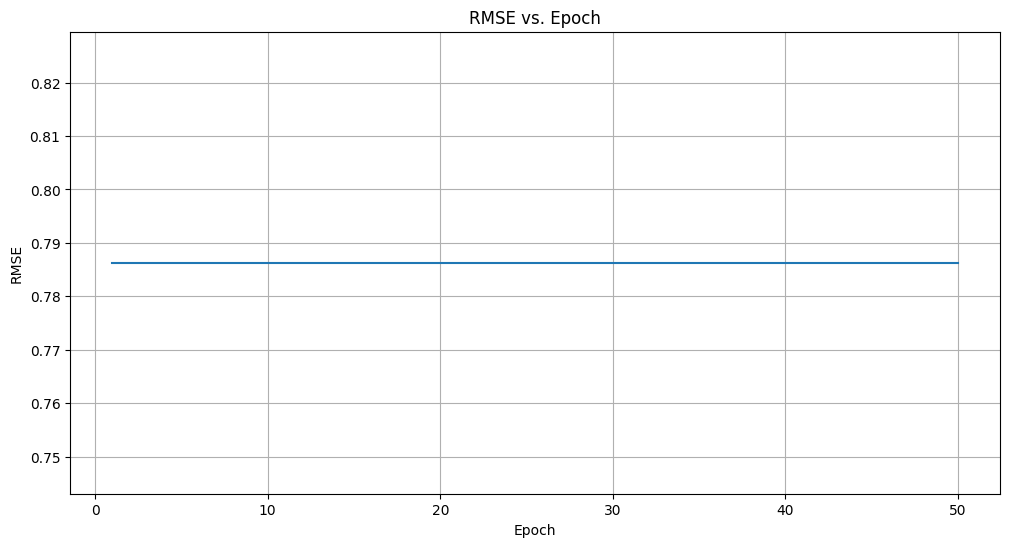

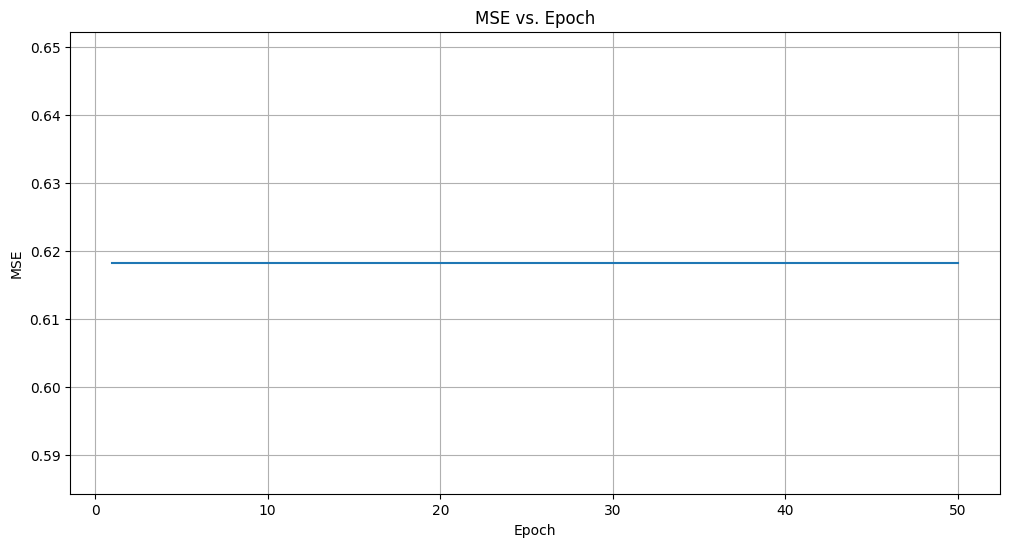

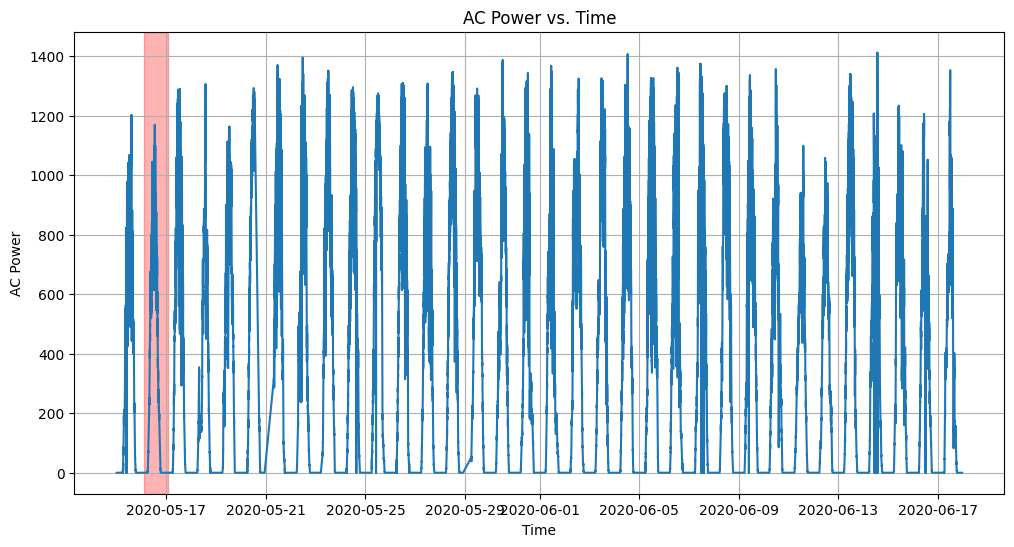

In [ ]:
import matplotlib.pyplot as plt

# Fit model with history to get loss values
history = model.fit(X_train_reshaped, y_train_scaled, epochs=50, batch_size=72, verbose=0)

# Plot loss vs. epoch
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.title('Model Loss vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# Calculate RMSE and MSE for each epoch
rmse_values = []
mse_values = []
for epoch in range(1, 51):
    y_pred_scaled = model.predict(X_test_reshaped)
    y_pred_inv = y_scaler.inverse_transform(y_pred_scaled)
    rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
    mse = mean_squared_error(y_test_inv, y_pred_inv)
    rmse_values.append(rmse)
    mse_values.append(mse)

# Plot RMSE vs. epoch
plt.figure(figsize=(12, 6))
plt.plot(range(1, 51), rmse_values)
plt.title('RMSE vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.grid(True)
plt.show()

# Plot MSE vs. epoch
plt.figure(figsize=(12, 6))
plt.plot(range(1, 51), mse_values)
plt.title('MSE vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.grid(True)
plt.show()

# Plot power vs. time with highlighted duration 2000-4000
plt.figure(figsize=(12, 6))
plt.plot(merged_data['DATE_TIME'], merged_data['AC_POWER'])
plt.axvspan(merged_data['DATE_TIME'].iloc[2000], merged_data['DATE_TIME'].iloc[4000], color='red', alpha=0.3)
plt.title('AC Power vs. Time')
plt.xlabel('Time')
plt.ylabel('AC Power')
plt.grid(True)
plt.show()
